In [43]:
import pandas as pd # importando biblioteca essencial

In [44]:
df = pd.read_excel('../data/data.xlsx') # lendo o arquivo excel e armazenando em um DataFrame

In [45]:
df.info() # exibindo informações sobre o DataFrame, como número de linhas, colunas e tipos de dados

<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 20 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Município de vacinação                              444 non-null    str    
 1   Idade Evento                                        444 non-null    float64
 2   Data da Notificação                                 444 non-null    object 
 3   Raça/Cor                                            444 non-null    object 
 4   Sexo                                                444 non-null    str    
 5   Imunobiológico (vacina)                             444 non-null    str    
 6   Dose                                                443 non-null    str    
 7   Gestante                                            444 non-null    object 
 8   Mês de gestação                                     444 non-null    float64
 9   Mulher ama

# Tratamento da coluna data

A coluna data não segue uma padronização clara. Enquanto algumas linhas apresentam apenas a informação do ano, outras apresentam a data completa.

É necessário tratar e padronizar a coluna de data.

In [46]:
# Convertendo a coluna 'Data da Notificação' para string e removendo espaços em branco
df['Data da Notificação'] = df['Data da Notificação'].astype(str).str.strip()

In [47]:
# Extraindo o ano da notificação e criando uma nova coluna 'Ano_Notificacao'
df['Ano_Notificacao'] = df['Data da Notificação'].str[:4]

In [48]:
# Convertendo de volta para o formato correto
df['Data_Completa_Notificacao'] = pd.to_datetime(df['Data da Notificação'], errors='coerce')

## Função de limpeza auxiliar

In [49]:
# Função para remover espaços, caracteres ocultos e padronizar maiúsculas
def limpar_e_padronizar_texto(texto):
    if pd.isna(texto):
        return None
    
    # Transforma em string e remove espaços normais nas pontas
    texto_str = str(texto).strip()
    
    # Remove quebras de linha e tabulações ocultas do Excel
    texto_str = pd.Series(texto_str).str.replace(r'[\r\n\t]+', '', regex=True).iloc[0]
    
    # Remove espaços duplos ou triplos no meio do texto
    texto_str = pd.Series(texto_str).str.replace(r'\s+', ' ', regex=True).iloc[0]
    
    # Força apenas a primeira letra em maiúscula para análise de termos
    texto_str = texto_str.capitalize()
    texto_lower = texto_str.lower()
    
    # Unifica todas as variações de Pfizer Pediátrica (com acento, sem acento ou erro de digitação)
    if 'pediat' in texto_lower or 'pediát' in texto_lower:
        if 'pfiz' in texto_lower or 'pfie' in texto_lower or 'pfzi' in texto_lower:
            return 'Pfizer pediátrica'
            
    # Unifica os erros de digitação da Pfizer convencional
    if 'pfiz' in texto_lower or 'pfzi' in texto_lower:
        if 'pediat' not in texto_lower and 'pediát' not in texto_lower and 'bival' not in texto_lower:
            return 'Pfizer'
            
    # Unifica os erros de digitação da Janssen
    if 'jans' in texto_lower or 'jass' in texto_lower:
        return 'Janssen'
    
    # Retorna None caso o resultado tenha ficado vazio
    if texto_str in ['Nan', 'None', '0', '']:
        return None
        
    return texto_str

# Tratando múltiplas informações nas colunas vacina e dose

As colunas vacina e dose apresentam mais de uma informação por entrada.
É de extrema importância dividir esses informações em colunas adjacentes, visando facilitar a busca, leitura e processamento dos dados nessas colunas.

In [50]:
# separando as vacinas pelo separador / e criando novas colunas para cada vacina
vacinas_separadas = df['Imunobiológico (vacina)'].str.split('/', expand=True).add_prefix('Vacina_')

In [51]:
# separando as doses pelo separador / e criando novas colunas para cada dose
doses_separadas = df['Dose'].str.split('/', expand=True).add_prefix('Dose_')

In [52]:
for col in vacinas_separadas.columns:
    vacinas_separadas[col] = vacinas_separadas[col].astype(str).str.replace(r'^\d+:\s*', '', regex=True)
    vacinas_separadas[col] = vacinas_separadas[col].apply(limpar_e_padronizar_texto)

for col in doses_separadas.columns:
    doses_separadas[col] = doses_separadas[col].astype(str).str.replace(r'^\d+:\s*', '', regex=True)
    doses_separadas[col] = doses_separadas[col].apply(limpar_e_padronizar_texto)

In [53]:
df = pd.concat([df, vacinas_separadas, doses_separadas], axis=1) # juntando as novas colunas de vacinas e doses ao DataFrame original

# Limpeza e Padronização dos Eventos e Desfechos

Vamos aplicar uma limpeza em lote nessas colunas de uma vez só, usando expressões regulares (regex) para remover os prefixos numéricos e os espaços em branco que sobram nas pontas.

In [54]:
colunas_para_limpar = [
    'Tipo de Evento', 
    'Reação / evento adverso', 
    'Classificação de gravidade', 
    'Desfecho (evolução do caso)'
]

# Limpeza padrão
for col in colunas_para_limpar:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace(r'^\d+:\s*', '', regex=True)
    df[col] = df[col].str.strip()
    df[col] = df[col].replace(['nan', 'NaN', '0', ''], None)

# Separar as colunas por barra '/'
eventos_separados = df['Tipo de Evento'].str.split('/', expand=True).add_prefix('Evento_')

for col in eventos_separados.columns:
    # Remove o padrão de numeração inicial e aplica a função de padronização completa
    eventos_separados[col] = eventos_separados[col].astype(str).str.replace(r'^\d+:\s*', '', regex=True)
    eventos_separados[col] = eventos_separados[col].apply(limpar_e_padronizar_texto)
    
    # Cria uma variável temporária em minúsculo para busca de termos específicos
    texto_lower = eventos_separados[col].astype(str).str.lower()
    
    # Substitui os textos com base nos termos encontrados independente da digitação original
    eventos_separados.loc[texto_lower.str.contains('erro') & texto_lower.str.contains('imuniza'), col] = 'Erro de Imunização'
    eventos_separados.loc[texto_lower.str.contains('evento') | texto_lower.str.contains('reaç') | texto_lower.str.contains('adverso'), col] = 'Evento Adverso'
    
    # Garante que textos vazios virem None de verdade
    eventos_separados[col] = eventos_separados[col].replace(['None', 'Nan', ''], None)

# Junta de volta no DataFrame principal
df = pd.concat([df, eventos_separados], axis=1)

# 5. Remove a coluna velha
df = df.drop(columns=['Tipo de Evento'], errors='ignore')

# Tratando colunas medicamentos e doenças

Muitas linhas nessas colunas vem com valor 0 ou 'Não' para indicar que a pessoa não tinha doenças ou usava medicamentos.
Devemos padronizar uma forma comum de sinalizar o que é "Sem informação".

In [55]:
colunas_finais = [
    'Doenças (CID10) - Preexistente', 
    'Medicamento em uso anterior ou durante a vacinação', 
    'Nome do Medicamento'
]

for col in colunas_finais:
    # Garantir que tudo seja texto e remover espaços extras nas pontas
    df[col] = df[col].astype(str).str.strip()
    
    # Remover prefixos numéricos 
    df[col] = df[col].str.replace(r'^\d+:\s*', '', regex=True)
    
    # Padronizar respostas negativas ou vazias para facilitar filtros futuros.
    
    valores_vazios = ['0', 'Não', 'Não ', 'nan', 'NaN', '-', '']
    df[col] = df[col].replace(valores_vazios, 'Não se aplica / Nenhum')

# Remoção de colunas duplicadas(geradas durante o tratamento)

In [56]:
colunas_para_remover = [
    'Data da Notificação',       # Já criamos 'Ano_Notificacao' e 'Data_Completa_Notificacao'
    'Imunobiológico (vacina)',   # Já virou 'Vacina_0', 'Vacina_1', etc.
    'Dose'                       # Já virou 'Dose_0', 'Dose_1', etc.
]

# O método .drop remove as colunas. 
# O errors='ignore' serve para o código não quebrar caso você rode o script de novo e a coluna já não exista.
df = df.drop(columns=colunas_para_remover, errors='ignore')

# Salvando localmente

Trecho simples para salvamendo local do novo DataFrame em um xlsx.

In [57]:
nome_do_arquivo = '../data/dados_tratados.xlsx'

df.to_excel(nome_do_arquivo, index=False)

# Gerando gráficos

In [58]:
import plotly.express as px # importando biblioteca para visualização de dados
import plotly.io as pio # importando módulo para configurar renderização de gráficos

pio.renderers.default = 'png' # renderizar como PNG. Remova se quiser gráficos interativos

## Distribuição evento X idade

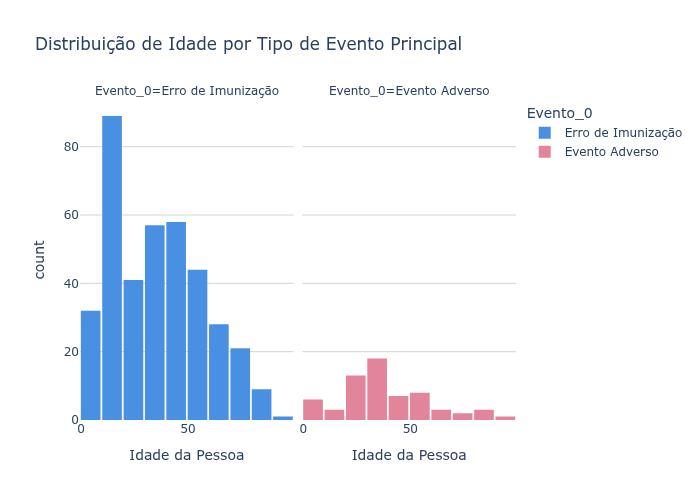

In [59]:
# Removemos apenas quem não tem idade ou evento principal preenchido

df_grafico = df.dropna(subset=['Idade Evento', 'Evento_0']).copy()

# Garante que a idade seja numérica
df_grafico['Idade Evento'] = pd.to_numeric(df_grafico['Idade Evento'], errors='coerce')
df_grafico = df_grafico.dropna(subset=['Idade Evento'])

# Criamos o Histograma dividido por colunas
fig_distribuicao = px.histogram(
    df_grafico, 
    x='Idade Evento', 
    facet_col='Evento_0',       # Cria um gráfico lado a lado para cada tipo de evento
    color='Evento_0',          
    nbins=12,  
    title='Distribuição de Idade por Tipo de Evento Principal',
    labels={'Idade Evento': 'Idade da Pessoa', 'count': 'Casos'},
    color_discrete_sequence=['#4A90E2', '#E2849A', '#A0D468'] # Cores limpas
)

# Ajustes visuais para garantir que fique idêntico a um relatório
fig_distribuicao.update_layout(
    plot_bgcolor='white',      
    font=dict(size=12),          
    bargap=0.08                  
)

# Adiciona linhas de grade horizontais e garante eixos independentes se necessário
fig_distribuicao.update_yaxes(showgrid=True, gridcolor='LightGrey')

fig_distribuicao.show()

## 

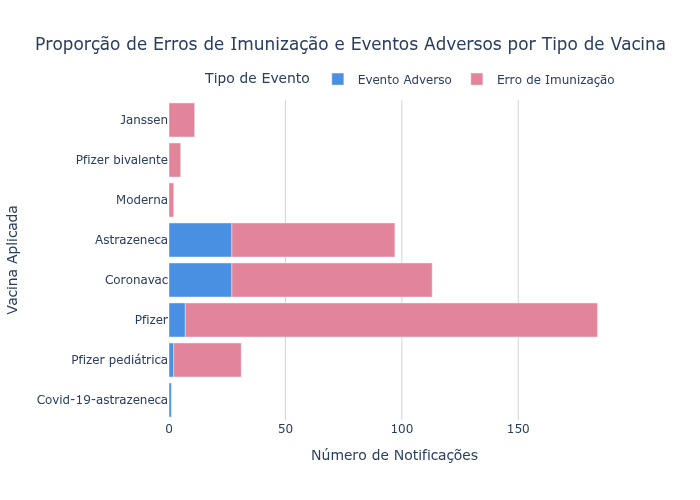

In [60]:
# Removemos quem não tem a vacina principal ou o evento principal preenchidos
df_vacinas = df.dropna(subset=['Vacina_0', 'Evento_0']).copy()

# Agrupamos os dados para contar a quantidade de casos por vacina e evento
df_contagem = df_vacinas.groupby(['Vacina_0', 'Evento_0']).size().reset_index(name='Quantidade')

# Ordenamos para que as vacinas com mais notificações fiquem no topo
df_contagem = df_contagem.sort_values(by='Quantidade', ascending=True)

# Criamos o gráfico de barras horizontais dividido por cores
fig_vacinas = px.bar(
    df_contagem,
    y='Vacina_0',
    x='Quantidade',
    color='Evento_0',
    orientation='h',
    title='Proporção de Erros de Imunização e Eventos Adversos por Tipo de Vacina',
    labels={'Vacina_0': 'Vacina Aplicada', 'Quantidade': 'Número de Notificações', 'Evento_0': 'Tipo de Evento'},
    color_discrete_sequence=['#4A90E2', '#E2849A']
)

# Ajustes visuais para garantir que fique idêntico a um relatório
fig_vacinas.update_layout(
    plot_bgcolor='white',
    font=dict(size=12),
    bargap=0.15,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# Adiciona linhas de grade horizontais e garante eixos independentes se necessário
fig_vacinas.update_xaxes(showgrid=True, gridcolor='LightGrey')

fig_vacinas.show()